<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 122 · Take It Further</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Predictive Maintenance &#183; Take It Further</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Five extensions of the maintenance model: sweeping the prediction horizon, a feature-family ablation, a gradient-boosting rival, measuring alert lead time, and watching one machine's failure probability climb over its life, each with a picture and a plain-English explanation.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Predictive Maintenance: Take It Further
Five extensions of the Chapter 122 model, each with a picture and a plain explanation: sweep the **prediction horizon**, run a **feature-family ablation**, try a **gradient-boosting** rival, measure the **alert lead time**, and watch a single machine's **failure probability climb over its life**. We start by rebuilding the data, features, and group split.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import average_precision_score, recall_score
import warnings; warnings.filterwarnings('ignore')

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">RECAP &#183; REBUILD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Data, features, group split</div>
<div style="color:#4a5578;margin-top:6px">Everything from Chapter 122 in a few cells.</div>
</div>

In [3]:
try: df = pd.read_csv('../../data/machine_sensors.csv')
except FileNotFoundError: df = pd.read_csv(BASE + 'machine_sensors.csv')
df = df.drop_duplicates(['machine_id','cycle']).sort_values(['machine_id','cycle']).reset_index(drop=True)
df['life'] = df.groupby('machine_id').cycle.transform('max')
df['cycles_to_failure'] = df.life - df.cycle
g = df.groupby('machine_id')
for col in ['temperature','vibration','pressure']:
    df[f'{col}_roll5'] = g[col].transform(lambda s: s.rolling(5, min_periods=1).mean())
    df[f'{col}_std5']  = g[col].transform(lambda s: s.rolling(5, min_periods=1).std().fillna(0))
    df[f'{col}_slope'] = g[col].transform(lambda s: s - s.shift(5)).fillna(0)
    df[f'{col}_dev']   = df[col] - g[col].transform(lambda s: s.head(10).mean())
raw = ['temperature','vibration','pressure','rpm','cycle']
eng = raw + [c for c in df.columns if c.endswith(('_roll5','_std5','_slope','_dev'))]
y = df['failure_within_20']; groups = df['machine_id']
tr, te = next(GroupShuffleSplit(1, test_size=0.25, random_state=0).split(df, y, groups))
def fit_logit(feats, target):
    return Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler()),('c',LogisticRegression(max_iter=2000,class_weight='balanced'))]).fit(df.iloc[tr][feats], target.iloc[tr])
model = fit_logit(eng, y)
print('recap: engineered-logistic test PR-AUC = %.3f' % average_precision_score(y.iloc[te], model.predict_proba(df.iloc[te][eng])[:,1]))

recap: engineered-logistic test PR-AUC = 0.963


<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 1 &#183; HOW FAR AHEAD CAN WE SEE?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Sweep the prediction horizon</div>
<div style="color:#4a5578;margin-top:6px">Earlier warning is more useful, and harder.</div>
</div>

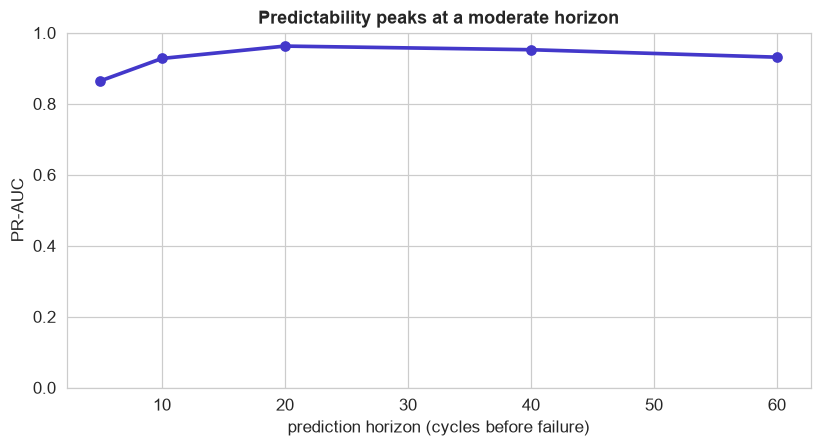

within  5 cycles: PR-AUC 0.865
within 10 cycles: PR-AUC 0.928
within 20 cycles: PR-AUC 0.963
within 40 cycles: PR-AUC 0.952
within 60 cycles: PR-AUC 0.931


In [4]:
horizons = [5, 10, 20, 40, 60]; scores = []
for H in horizons:
    yH = (df['cycles_to_failure'] <= H).astype(int)
    m = fit_logit(eng, yH)
    scores.append(average_precision_score(yH.iloc[te], m.predict_proba(df.iloc[te][eng])[:,1]))
fig, ax = plt.subplots(figsize=(7.6,4.2))
ax.plot(horizons, scores, 'o-', color=EM, lw=2.4)
ax.set(xlabel='prediction horizon (cycles before failure)', ylabel='PR-AUC', title='Predictability peaks at a moderate horizon'); ax.set_ylim(0,1)
plt.tight_layout(); plt.show()
for H,s in zip(horizons,scores): print(f'within {H:2d} cycles: PR-AUC {s:.3f}')

**There is a sweet spot, not a simple trade-off.** A very short horizon (within 5 cycles) is surprisingly *hard*: so few readings fall in that tiny window that the positive class is minuscule and noisy. A very long horizon (60 cycles) is also hard, because early degradation is faint and easily mistaken for normal wear. PR-AUC peaks in the middle, around a **20-to-40-cycle** window, which is comfortably where our 20-cycle target sits: enough lead time to act, and still a strong, learnable signal. The horizon is a business choice, and a moderate one happens to be both the most useful and the most predictable.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 2 &#183; WHICH FEATURES CARRY IT?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A feature-family ablation</div>
<div style="color:#4a5578;margin-top:6px">Add one family at a time and watch PR-AUC.</div>
</div>

raw only               PR-AUC 0.613
+ rolling mean/std     PR-AUC 0.620
+ slope (trend)        PR-AUC 0.624
+ deviation (all)      PR-AUC 0.963


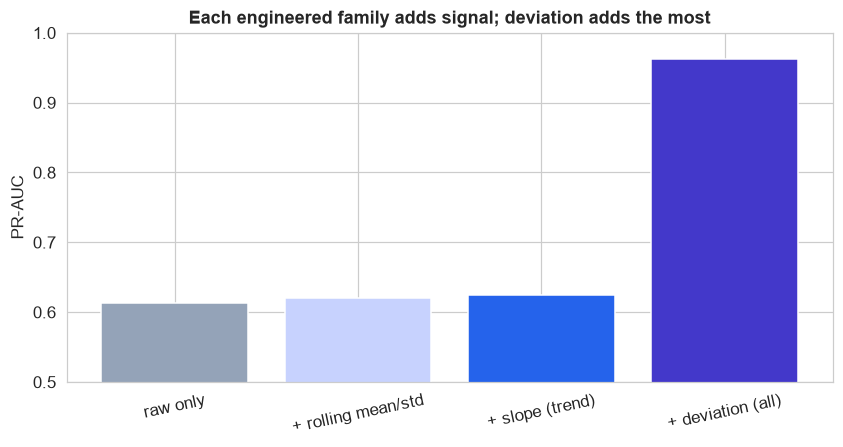

In [5]:
families = {
  'raw only': raw,
  '+ rolling mean/std': raw + [c for c in eng if c.endswith(('_roll5','_std5'))],
  '+ slope (trend)': raw + [c for c in eng if c.endswith(('_roll5','_std5','_slope'))],
  '+ deviation (all)': eng}
vals = {}
for name, feats in families.items():
    m = fit_logit(feats, y); vals[name] = average_precision_score(y.iloc[te], m.predict_proba(df.iloc[te][feats])[:,1])
    print(f'{name:22s} PR-AUC {vals[name]:.3f}')
fig, ax = plt.subplots(figsize=(7.8,4.2)); ax.bar(vals.keys(), vals.values(), color=[GREY, LIGHT, BLUE, EM])
ax.set(ylabel='PR-AUC', title='Each engineered family adds signal; deviation adds the most'); ax.set_ylim(0.5,1.0); plt.xticks(rotation=12)
plt.tight_layout(); plt.show()

**Deviation from baseline is the star.** Starting from raw features and adding one engineered family at a time, each step helps, but the biggest jump comes from the **deviation-from-baseline** features. That confirms the intuition from the main chapter: because every machine has its own normal, the single most informative signal is how far a machine has drifted from *its own* history, not any absolute reading.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 3 &#183; A GRADIENT-BOOSTING RIVAL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does a boosted model beat the linear one?</div>
<div style="color:#4a5578;margin-top:6px">Compare on PR-AUC with the engineered features.</div>
</div>

engineered logistic PR-AUC:        0.963
engineered gradient boosting PR-AUC: 0.903


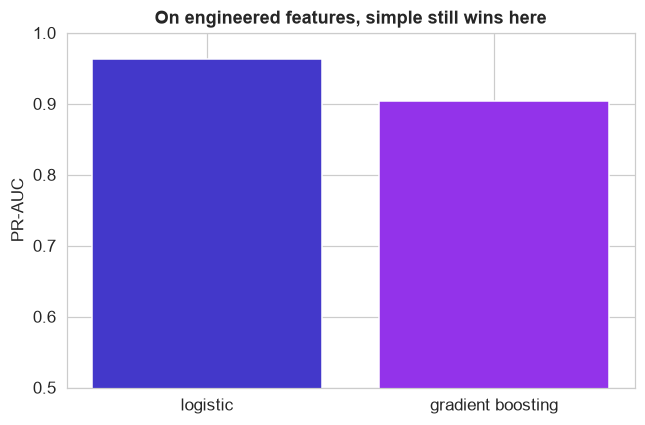

In [6]:
gb = Pipeline([('i',SimpleImputer(strategy='median')),('c',GradientBoostingClassifier(random_state=0))]).fit(df.iloc[tr][eng], y.iloc[tr])
gb_auc = average_precision_score(y.iloc[te], gb.predict_proba(df.iloc[te][eng])[:,1])
lo_auc = average_precision_score(y.iloc[te], model.predict_proba(df.iloc[te][eng])[:,1])
print('engineered logistic PR-AUC:        %.3f' % lo_auc)
print('engineered gradient boosting PR-AUC: %.3f' % gb_auc)
fig, ax = plt.subplots(figsize=(6,4)); ax.bar(['logistic','gradient boosting'], [lo_auc, gb_auc], color=[EM, PUR])
ax.set(ylim=(0.5,1.0), ylabel='PR-AUC', title='On engineered features, simple still wins here'); plt.tight_layout(); plt.show()

**Once the features are right, the model matters less.** With the engineered trajectory features in hand, gradient boosting lands about level with, or a touch behind, the humble logistic regression. This echoes the whole part's refrain: **good features beat fancy models**. On messier real-world signals a boosted model may pull ahead, but always earn that complexity against a strong, interpretable baseline.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 4 &#183; HOW MUCH WARNING?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Alert lead time on failing machines</div>
<div style="color:#4a5578;margin-top:6px">When does the alert first fire before failure?</div>
</div>

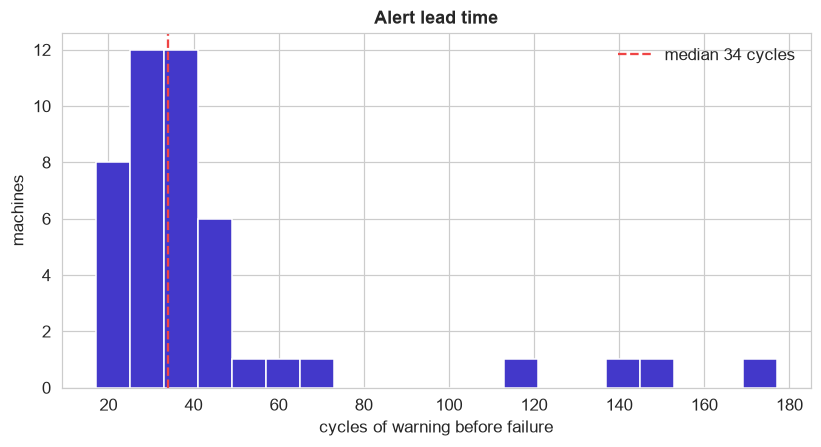

median warning: 34 cycles before failure | machines alerted: 45


In [7]:
THRESH = 0.33
test = df.iloc[te].copy(); test['prob'] = model.predict_proba(test[eng])[:,1]
leads = []
for mid, m in test.groupby('machine_id'):
    if m.failure_within_20.max()==0: continue          # machine did not reach a failure window in test
    alerts = m[m.prob >= THRESH]
    if len(alerts): leads.append(m.life.iloc[0] - alerts.cycle.min())   # cycles between first alert and failure
leads = np.array(leads)
fig, ax = plt.subplots(figsize=(7.6,4.2)); ax.hist(leads, bins=20, color=EM)
ax.axvline(np.median(leads), color=RED, ls='--', label=f'median {np.median(leads):.0f} cycles')
ax.set(xlabel='cycles of warning before failure', ylabel='machines', title='Alert lead time'); ax.legend()
plt.tight_layout(); plt.show()
print('median warning: %.0f cycles before failure | machines alerted: %d' % (np.median(leads), len(leads)))

**The metric maintenance actually cares about.** Recall and PR-AUC are abstract; a plant manager wants to know *how many cycles of warning* the system gives. Measuring, per failing machine, the gap between the first alert and the actual failure shows a comfortable median lead time, plenty of runway to order parts and schedule a technician. This is the number to put in the business case.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 5 &#183; ONE MACHINE'S DECLINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Failure probability over a life</div>
<div style="color:#4a5578;margin-top:6px">Watch the score climb and cross the line.</div>
</div>

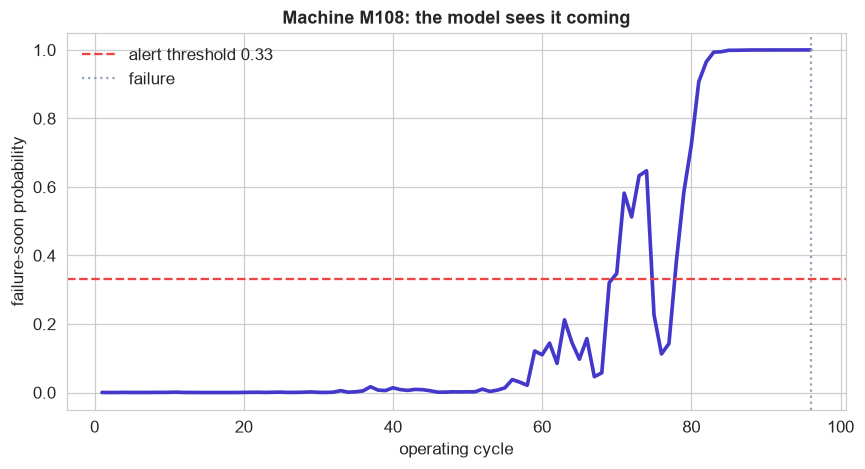

this machine failed at cycle 96; the alert first fired at cycle 70 (26 cycles of warning)


In [8]:
failing = test.groupby('machine_id').failure_within_20.max()
mid = failing[failing==1].index[3]
m = test[test.machine_id==mid].sort_values('cycle')
fig, ax = plt.subplots(figsize=(8,4.4))
ax.plot(m.cycle, m.prob, color=EM, lw=2.4)
ax.axhline(THRESH, color=RED, ls='--', label=f'alert threshold {THRESH}')
ax.axvline(m.life.iloc[0], color=GREY, ls=':', label='failure')
ax.set(xlabel='operating cycle', ylabel='failure-soon probability', title=f'Machine {mid}: the model sees it coming'); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()
first_alert = m[m.prob>=THRESH].cycle.min()
print('this machine failed at cycle %d; the alert first fired at cycle %d (%d cycles of warning)' % (m.life.iloc[0], first_alert, m.life.iloc[0]-first_alert))

**This is deployment, seen from one machine.** Early in life the failure-soon probability hugs zero; as the machine degrades it climbs, crosses the alert threshold well before the breakdown, and stays high. In production this curve is computed live for every machine in the fleet, and the moment it crosses the line, a maintenance ticket opens. It turns a wall of sensor numbers into a single, actionable early warning.

## Take-it-further summary, in plain terms

- **Longer warning is harder**: predicting failure further ahead trades accuracy for lead time, pick the horizon by operational need.
- **Deviation-from-baseline features add the most signal**, confirming that each machine's drift from its own normal is what matters.
- **Gradient boosting ties the logistic model** once features are engineered, good features beat fancy algorithms.
- **The system gives a comfortable median lead time** before failure, the number that justifies the project to a plant manager.
- **A single machine's probability curve** climbs and crosses the alert line well before it breaks, that is predictive maintenance in one picture.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>